# 03 – Convergencia de Monte Carlo para pricing de opciones

En este notebook estudiamos cómo el estimador de Monte Carlo del precio de una call europea converge al valor analítico de Black-Scholes cuando aumentamos el número de trayectorias simuladas.

Se espera que el error absoluto decaiga como $O(1/\sqrt{n})$, lo que corresponde a una pendiente de $-1/2$ en escala log-log.

Parámetros: $S=100$, $K=100$, $T=1$, $r=0.05$, $\sigma=0.2$.

In [7]:
import sys
from pathlib import Path

sys.path.append(str(Path(".").resolve().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from black_scholes import call_price
from simulation import mc_call_price

plt.style.use("seaborn-v0_8-whitegrid")
%matplotlib inline

## 1. Parámetros y precio analítico de referencia

In [8]:
S = 100
K = 100
T = 1.0
r = 0.05
sigma = 0.2
q = 0.0

bs_price = call_price(S, K, T, r, sigma, q)
print(f"Precio Black-Scholes (referencia exacta): {bs_price:.6f}")

Precio Black-Scholes (referencia exacta): 10.450584


## 2. Simulaciones para distintos números de trayectorias

Para cada cantidad de paths realizamos varias repeticiones con semillas distintas y promediamos, reduciendo la variabilidad puntual del estimador y dejando visible la tendencia teórica de decaimiento.

In [3]:
n_values = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000, 500000]
n_reps = 20  # repeticiones por cada n
base_seed = 42

records = []

for n_idx, n in enumerate(n_values):
    prices = []
    std_errors = []
    for rep in range(n_reps):
        # Semilla distinta para cada combinación (n, repetición)
        seed = base_seed + n_idx * 1000 + rep
        price, se = mc_call_price(S, K, T, r, sigma, n_paths=n, n_steps=1, random_state=seed)
        prices.append(price)
        std_errors.append(se)

    prices = np.array(prices)
    std_errors = np.array(std_errors)

    mean_price = prices.mean()
    mean_abs_error = np.abs(prices - bs_price).mean()
    mean_se = std_errors.mean()

    records.append({
        "n_paths": n,
        "mean_mc_price": mean_price,
        "mean_abs_error": mean_abs_error,
        "mean_se": mean_se,
        "bs_price": bs_price,
    })

results = pd.DataFrame(records)
results

,n_paths,mean_mc_price,mean_abs_error,mean_se,bs_price
0,10,10.788499,4.320207,4.148396,10.450584
1,50,9.964858,1.468890,1.932597,10.450584
2,100,10.344291,1.602036,1.447562,10.450584
3,500,10.358794,0.579911,0.646366,10.450584
4,1000,10.345743,0.357841,0.458349,10.450584
5,5000,10.523726,0.180345,0.208012,10.450584
6,10000,10.454195,0.134658,0.147441,10.450584
7,50000,10.458249,0.056231,0.065800,10.450584
8,100000,10.446714,0.036574,0.046544,10.450584
9,500000,10.444982,0.015953,0.020817,10.450584


## 3. Tabla de resultados

In [4]:
display_cols = ["n_paths", "mean_mc_price", "bs_price", "mean_abs_error", "mean_se"]
results[display_cols].style.format({
    "mean_mc_price": "{:.6f}",
    "bs_price": "{:.6f}",
    "mean_abs_error": "{:.6f}",
    "mean_se": "{:.6f}"
})

,n_paths,mean_mc_price,bs_price,mean_abs_error,mean_se
0,10,10.788499,10.450584,4.320207,4.148396
1,50,9.964858,10.450584,1.468890,1.932597
2,100,10.344291,10.450584,1.602036,1.447562
3,500,10.358794,10.450584,0.579911,0.646366
4,1000,10.345743,10.450584,0.357841,0.458349
5,5000,10.523726,10.450584,0.180345,0.208012
6,10000,10.454195,10.450584,0.134658,0.147441
7,50000,10.458249,10.450584,0.056231,0.065800
8,100000,10.446714,10.450584,0.036574,0.046544
9,500000,10.444982,10.450584,0.015953,0.020817


## 4. Gráficos de convergencia

A la izquierda: error absoluto medio vs. $n$ en escala log-log, con la referencia teórica $1/\sqrt{n}$ y el error estándar teórico medio.

A la derecha: precio Monte Carlo medio con banda ±1 SE en torno al precio, comparado con el precio Black-Scholes exacto.

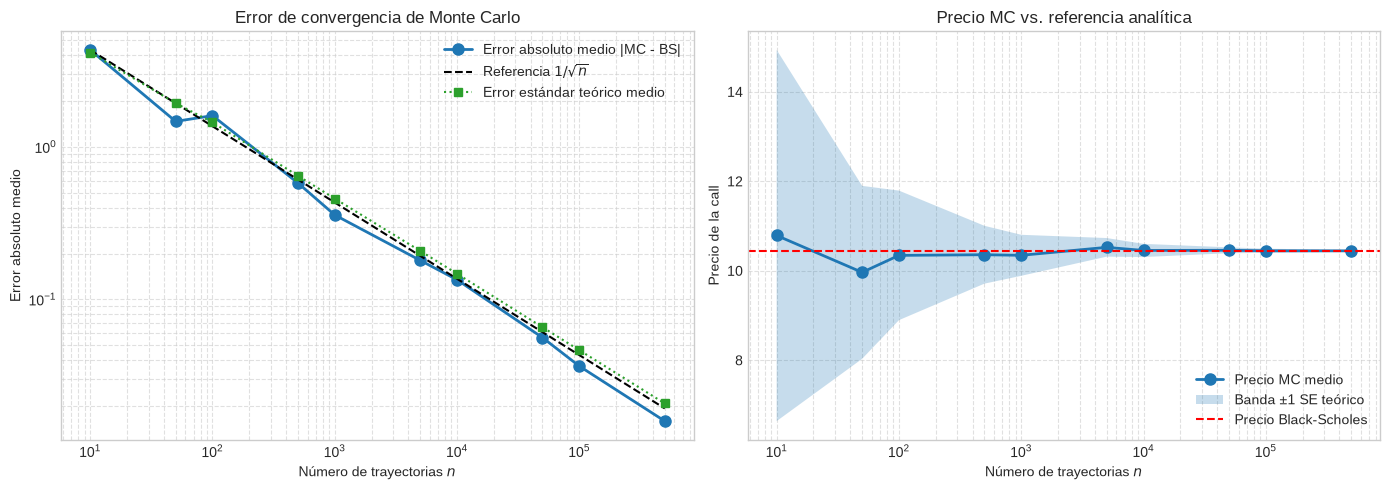

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_arr = results["n_paths"].values
err_arr = results["mean_abs_error"].values
se_arr = results["mean_se"].values
price_arr = results["mean_mc_price"].values

# --- Subplot 1: error absoluto en escala log-log ---
ax = axes[0]

# Referencia teórica 1/sqrt(n), ajustada al primer punto
ref_const = err_arr[0] * np.sqrt(n_arr[0])
ref_line = ref_const / np.sqrt(n_arr)

ax.loglog(n_arr, err_arr, "o-", label="Error absoluto medio |MC - BS|", linewidth=2, markersize=8)
ax.loglog(n_arr, ref_line, "k--", label=r"Referencia $1/\sqrt{n}$", linewidth=1.5)
ax.loglog(n_arr, se_arr, "s:", label="Error estándar teórico medio", color="tab:green", markersize=6)

ax.set_xlabel("Número de trayectorias $n$")
ax.set_ylabel("Error absoluto medio")
ax.set_title("Error de convergencia de Monte Carlo")
ax.legend(loc="upper right")
ax.grid(True, which="both", linestyle="--", alpha=0.6)

# --- Subplot 2: precio MC con banda de confianza ---
ax = axes[1]

ax.plot(n_arr, price_arr, "o-", label="Precio MC medio", linewidth=2, markersize=8)
ax.fill_between(
    n_arr,
    price_arr - se_arr,
    price_arr + se_arr,
    alpha=0.25,
    label="Banda ±1 SE teórico"
)
ax.axhline(bs_price, color="red", linestyle="--", label="Precio Black-Scholes")
ax.set_xscale("log")
ax.set_xlabel("Número de trayectorias $n$")
ax.set_ylabel("Precio de la call")
ax.set_title("Precio MC vs. referencia analítica")
ax.legend(loc="lower right")
ax.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## 5. Verificación numérica de la pendiente

In [6]:
# Regresión lineal de log(error) vs log(n) para estimar la pendiente
log_n = np.log(n_arr)
log_err = np.log(err_arr)
slope, intercept = np.polyfit(log_n, log_err, 1)

print(f"Pendiente estimada en escala log-log: {slope:.4f}")
print(f"Pendiente teórica esperada: -0.5")
print(f"Diferencia: {abs(slope + 0.5):.4f}")

Pendiente estimada en escala log-log: -0.5109
Pendiente teórica esperada: -0.5
Diferencia: 0.0109


## Ejercicios propuestos

1. Repetir el análisis para una put europea y verificar que también se obtiene la convergencia $O(1/\sqrt{n})$.
2. Probar con $n$ más grande (por ejemplo, $10^6$ o $10^7$) y observar hasta dónde se mantiene la tendencia.
3. Variar la cantidad de repeticiones por cada $n$. ¿A partir de cuántas repeticiones el gráfico se estabiliza?